<a href="https://colab.research.google.com/github/OJB-Quantum/Qiskit-Metal-to-Litho/blob/main/Quantum_Metal_PHIDL_GDSTK_CuPy_Headless_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Headless Quantum Metal + PHIDL + GDSTK + CuPy workflow for Colab

This notebook runs a headless layout workflow that combines Quantum Metal (formerly Qiskit Metal), PHIDL, GDSTK, and an optional CuPy backend on a Colab T4 GPU.

Run the first installation cell once in a fresh Colab runtime. Colab will restart the runtime after the compiled binary stack is installed.

The layout workflow executes four distinct stages that begin by cloning and patching Quantum Metal from GitHub for layout-only headless imports, which seamlessly transitions into running a CuPy or NumPy transmon geometry proxy sweep. Subsequently, the process generates independent PHIDL helper geometry and constructs a Quantum Metal transmon that converts available QGeometry tables to GDSTK, which ultimately allows the system to merge the PHIDL, Quantum Metal, and placeholder junction GDS files into a unified output.


In [1]:
"""
This script demonstrates a headless computational stack suitable for quantum hardware engineering
and Electronic Design Automation (EDA) workflows using Quantum Metal, PHIDL, GDSTK, and CuPy.
"""

import os
import subprocess
import sys
from pathlib import Path
from typing import Final

# =============================================================================
# CONTROL KNOBS
# =============================================================================

FORCE_CLEAN_INSTALL: Final[bool] = False
RESTART_AFTER_INSTALL: Final[bool] = True
INSTALL_SENTINEL: Final[Path] = Path("/content/.qm_headless_colab_stack")

QT_QPA_PLATFORM: Final[str] = "offscreen"
MPLBACKEND: Final[str] = "Agg"

BINARY_FOUNDATION_PACKAGES: Final[list[str]] = [
    "numpy==1.26.4",
    "pandas==2.2.2",
    "scipy==1.14.1",
    "matplotlib==3.8.4",
    "h5py==3.11.0",
]

EDA_PACKAGES: Final[list[str]] = [
    "gdstk>=0.9.61,<1.0.0",
    "shapely>=2.0.0,<3.0.0",
    "ezdxf>=1.2.0,<2.0.0",
    "phidl>=1.7.2,<2.0.0",
    "networkx>=2.8",
    "pint>=0.20",
    "addict>=2.4.0",
    "pyyaml>=6.0.1",
    "descartes>=1.1",
    "jedi>=0.19.1",
]

GPU_PACKAGES: Final[list[str]] = [
    "cupy-cuda12x>=13.0.0,<14.0.0",
]

os.environ["QT_QPA_PLATFORM"] = QT_QPA_PLATFORM
os.environ["MPLBACKEND"] = MPLBACKEND


def run_command(command: list[str]) -> None:
    """Execute a synchronous subprocess command and raise an exception upon failure."""
    print(f"Executing: {' '.join(command)}")
    subprocess.check_call(command)


def purge_loaded_modules(target_modules: tuple[str, ...]) -> None:
    """Unload specific modules from the system registry to prevent binary conflicts."""
    for module in list(sys.modules.keys()):
        if any(module == target or module.startswith(f"{target}.") for target in target_modules):
            del sys.modules[module]


def install_stack() -> None:
    """Install a coherent compiled package stack specifically tailored for the notebook."""
    target_binaries: tuple[str, ...] = ("numpy", "pandas", "scipy", "matplotlib", "h5py")

    purge_loaded_modules(target_binaries)

    run_command([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "pip", "wheel", "setuptools"])

    run_command([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "--force-reinstall", "--no-cache-dir", "--prefer-binary",
        *BINARY_FOUNDATION_PACKAGES
    ])

    run_command([
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "--no-cache-dir", "--prefer-binary",
        *EDA_PACKAGES, *GPU_PACKAGES
    ])


if FORCE_CLEAN_INSTALL or INSTALL_SENTINEL.exists() == False:
    install_stack()
    INSTALL_SENTINEL.write_text("installed\n", encoding="utf-8")
    print("Dependency installation concluded successfully.")

    if RESTART_AFTER_INSTALL:
        print("Restarting the runtime environment gracefully to apply changes.")
        import IPython
        IPython.Application.instance().kernel.do_shutdown(True)
else:
    print("Installation sentinel detected. Proceeding with execution.")

Installation sentinel detected. Proceeding with execution.


In [2]:
#@title 2. Verify ABI compatibility and select NumPy or CuPy backend
"""Import the scientific stack after the install-time runtime restart."""

import os
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Final

os.environ.setdefault("QT_QPA_PLATFORM", "offscreen")
os.environ.setdefault("MPLBACKEND", "Agg")

try:
    import matplotlib as mpl

    mpl.use("Agg", force=True)
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
except ValueError as abi_error:
    raise RuntimeError(
        "NumPy/Pandas ABI mismatch remains. Run cell 1 in a fresh runtime, "
        "allow the restart, and then continue from this cell."
    ) from abi_error

# =============================================================================
# CONTROL KNOBS
# =============================================================================

USE_CUPY_WHEN_AVAILABLE: Final[bool] = True
MPL_DPI: Final[int] = 250

mpl.rcParams["figure.dpi"] = MPL_DPI
mpl.rcParams["savefig.dpi"] = MPL_DPI

cp = None
USING_CUPY = False
CUPY_IMPORT_ERROR = None

if USE_CUPY_WHEN_AVAILABLE:
    try:
        import cupy as cp_candidate

        GPU_COUNT = cp_candidate.cuda.runtime.getDeviceCount()
        USING_CUPY = GPU_COUNT > 0
        cp = cp_candidate if USING_CUPY else None
    except Exception as error:  # noqa: BLE001
        CUPY_IMPORT_ERROR = error

XP = cp if USING_CUPY and cp is not None else np


def to_numpy(array: Any) -> np.ndarray:
    """Return a NumPy array from a NumPy or CuPy object."""
    if USING_CUPY and cp is not None:
        return cp.asnumpy(array)
    return np.asarray(array)


def get_gpu_name() -> str:
    """Return the active CUDA device name when CuPy can access a GPU."""
    if not USING_CUPY or cp is None:
        return "CPU fallback"

    properties = cp.cuda.runtime.getDeviceProperties(0)
    name = properties["name"]
    if isinstance(name, bytes):
        return name.decode("utf-8")
    return str(name)


print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {mpl.__version__}")
print(f"Matplotlib backend: {mpl.get_backend()}")

if USING_CUPY:
    print(f"CuPy version: {cp.__version__}")
    print(f"CUDA device: {get_gpu_name()}")
else:
    print("CuPy GPU backend unavailable. NumPy fallback is active.")
    if CUPY_IMPORT_ERROR is not None:
        print(f"CuPy import or CUDA check error: {CUPY_IMPORT_ERROR}")


NumPy version: 1.26.4
Pandas version: 2.2.2
Matplotlib version: 3.8.4
Matplotlib backend: agg
CuPy version: 13.6.0
CUDA device: Tesla T4


In [3]:
#@title 3. Clone and patch Quantum Metal for headless layout-only imports
"""Clone Quantum Metal, patch GUI-sensitive imports, and bind the local clone."""

import importlib
import os
import re
import shutil
import subprocess
import sys
import textwrap
from pathlib import Path
from typing import Final

# =============================================================================
# CONTROL KNOBS
# =============================================================================

USE_FRESH_QISKIT_METAL_CLONE: Final[bool] = True
QISKIT_METAL_REPO_URL: Final[str] = "https://github.com/qiskit-community/qiskit-metal"
QISKIT_METAL_ROOT: Final[Path] = Path("/content/qiskit-metal")


def run_command(command: list[str], cwd: Path | None = None) -> None:
    """Run a subprocess command and raise if it fails."""
    print("Running:", " ".join(command))
    subprocess.check_call(command, cwd=str(cwd) if cwd else None)


def clear_qiskit_metal_modules() -> None:
    """Remove cached qiskit_metal modules so patched files are reimported."""
    for module_name in list(sys.modules):
        if module_name == "qiskit_metal" or module_name.startswith("qiskit_metal."):
            del sys.modules[module_name]


def clone_qiskit_metal() -> None:
    """Clone the current Qiskit Metal repository into /content."""
    if USE_FRESH_QISKIT_METAL_CLONE and QISKIT_METAL_ROOT.exists():
        shutil.rmtree(QISKIT_METAL_ROOT)

    if not QISKIT_METAL_ROOT.exists():
        run_command(
            [
                "git",
                "clone",
                "--depth",
                "1",
                QISKIT_METAL_REPO_URL,
                str(QISKIT_METAL_ROOT),
            ]
        )
    else:
        print(f"Using existing repository: {QISKIT_METAL_ROOT}")


def find_qiskit_metal_package() -> tuple[Path, Path]:
    """Return the import root and qiskit_metal package directory."""
    candidates = [
        QISKIT_METAL_ROOT / "qiskit_metal",
        QISKIT_METAL_ROOT / "src" / "qiskit_metal",
    ]

    for package_dir in candidates:
        if package_dir.exists():
            return package_dir.parent, package_dir

    raise FileNotFoundError(
        "Could not find qiskit_metal under /content/qiskit-metal. "
        f"Checked: {candidates}"
    )


def backup_file(path: Path) -> None:
    """Create a one-time backup of a file before patching it."""
    backup_path = path.with_name(f"{path.stem}__orig{path.suffix}")
    if path.exists() and not backup_path.exists():
        backup_path.write_text(path.read_text(encoding="utf-8"), encoding="utf-8")


def write_minimal_qiskit_metal_init(package_dir: Path) -> None:
    """Replace qiskit_metal.__init__ with a headless layout-only surface."""
    init_path = package_dir / "__init__.py"
    backup_file(init_path)
    minimal_init = textwrap.dedent(
        """
        # [colab] Headless, layout-only __init__ for Qiskit Metal.
        import logging as _logging

        try:
            from addict import Dict as Dict
        except Exception:
            from .toolbox_python.attr_dict import Dict

        logger = _logging.getLogger("qiskit_metal_colab")

        class _Config:
            @staticmethod
            def is_building_docs():
                return False

        config = _Config()

        def is_design(obj):
            try:
                from .designs.design_base import QDesign
                return isinstance(obj, QDesign)
            except Exception:
                return False

        def is_component(obj):
            try:
                from .qlibrary.core.base import QComponent
                return isinstance(obj, QComponent)
            except Exception:
                return False

        __all__ = ["Dict", "config", "logger", "is_design", "is_component"]
        """
    ).strip() + "\n"
    init_path.write_text(minimal_init, encoding="utf-8")


def patch_draw_package(package_dir: Path) -> None:
    """Guard draw.mpl imports so Qt/PySide does not load during imports."""
    draw_init = package_dir / "draw" / "__init__.py"
    if not draw_init.exists():
        return

    backup_file(draw_init)
    text = draw_init.read_text(encoding="utf-8")
    text = re.sub(
        r"^\s*from\s+\.\s*import\s+mpl\s*$",
        "try:\n"
        "    from . import mpl\n"
        "except Exception as _draw_mpl_error:\n"
        "    print('[colab] draw.mpl disabled in headless mode:', _draw_mpl_error)\n",
        text,
        flags=re.MULTILINE,
    )
    text = re.sub(
        r"^\s*from\s+\.mpl\s+import[^\n]*$",
        "try:\n"
        "    from .mpl import render, figure_spawn\n"
        "except Exception as _draw_named_error:\n"
        "    print('[colab] draw.mpl named imports disabled:', _draw_named_error)\n"
        "    def render(*args, **kwargs):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n"
        "    def figure_spawn(*args, **kwargs):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n",
        text,
        flags=re.MULTILINE,
    )
    draw_init.write_text(text, encoding="utf-8")


def patch_renderers_package(package_dir: Path) -> None:
    """Keep renderer imports explicit to avoid Qt/MPL side effects."""
    renderer_init = package_dir / "renderers" / "__init__.py"
    if not renderer_init.exists():
        return

    backup_file(renderer_init)
    renderer_init.write_text(
        "# [colab] minimal renderers package. Use explicit renderer imports only.\n"
        "__all__ = []\n",
        encoding="utf-8",
    )


def setup_headless_qiskit_metal() -> Path:
    """Clone, patch, and bind Qiskit Metal to the current interpreter."""
    clone_qiskit_metal()
    import_root, package_dir = find_qiskit_metal_package()

    write_minimal_qiskit_metal_init(package_dir)
    patch_draw_package(package_dir)
    patch_renderers_package(package_dir)

    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))

    existing_pythonpath = os.environ.get("PYTHONPATH", "")
    os.environ["PYTHONPATH"] = (
        str(import_root)
        if not existing_pythonpath
        else f"{import_root}:{existing_pythonpath}"
    )

    clear_qiskit_metal_modules()
    importlib.invalidate_caches()

    import qiskit_metal

    imported_from = Path(qiskit_metal.__file__).resolve()
    expected_root = package_dir.resolve()
    expected_init = expected_root / "__init__.py"
    if imported_from != expected_init:
        raise RuntimeError(
            "qiskit_metal imported from the wrong location. "
            f"Imported from {imported_from}; expected {expected_init}."
        )

    print("qiskit_metal from:", imported_from)
    return package_dir


QISKIT_METAL_PACKAGE_DIR = setup_headless_qiskit_metal()


Running: git clone --depth 1 https://github.com/qiskit-community/qiskit-metal /content/qiskit-metal
qiskit_metal from: /content/qiskit-metal/src/qiskit_metal/__init__.py


In [4]:
#@title 4. Run a CuPy or NumPy transmon geometry proxy sweep
"""Use the selected array backend to choose a compact transmon geometry."""

from dataclasses import dataclass
from typing import Final

# =============================================================================
# CONTROL KNOBS
# =============================================================================

PAD_WIDTH_RANGE_UM: Final[tuple[float, float]] = (260.0, 520.0)
PAD_HEIGHT_RANGE_UM: Final[tuple[float, float]] = (60.0, 160.0)
PAD_GAP_RANGE_UM: Final[tuple[float, float]] = (18.0, 70.0)
POCKET_MARGIN_UM: Final[float] = 180.0
SWEEP_POINTS_PER_AXIS: Final[int] = 48
TARGET_CAP_PROXY: Final[float] = 2_700.0
COMPACTNESS_WEIGHT: Final[float] = 0.18


@dataclass(frozen=True)
class SweepResult:
    """Compact record of the selected geometric design point."""

    pad_width_um: float
    pad_gap_um: float
    pad_height_um: float
    pocket_width_um: float
    pocket_height_um: float
    cap_proxy: float
    compactness_proxy: float
    score: float


def sweep_best_geometry() -> SweepResult:
    """Sweep simple transmon geometry proxies and return the best candidate."""
    pad_width = XP.linspace(*PAD_WIDTH_RANGE_UM, SWEEP_POINTS_PER_AXIS)
    pad_height = XP.linspace(*PAD_HEIGHT_RANGE_UM, SWEEP_POINTS_PER_AXIS)
    pad_gap = XP.linspace(*PAD_GAP_RANGE_UM, SWEEP_POINTS_PER_AXIS)

    width_grid, height_grid, gap_grid = XP.meshgrid(
        pad_width,
        pad_height,
        pad_gap,
        indexing="ij",
    )

    cap_proxy = width_grid * height_grid / gap_grid
    pocket_width = 2.0 * width_grid + gap_grid + POCKET_MARGIN_UM
    pocket_height = height_grid + POCKET_MARGIN_UM
    compactness_proxy = pocket_width * pocket_height

    score = ((cap_proxy - TARGET_CAP_PROXY) / TARGET_CAP_PROXY) ** 2
    score += COMPACTNESS_WEIGHT * compactness_proxy / XP.max(compactness_proxy)

    best_index = int(to_numpy(XP.argmin(score)))
    unravelled = np.unravel_index(best_index, tuple(score.shape))

    return SweepResult(
        pad_width_um=float(to_numpy(width_grid[unravelled])),
        pad_gap_um=float(to_numpy(gap_grid[unravelled])),
        pad_height_um=float(to_numpy(height_grid[unravelled])),
        pocket_width_um=float(to_numpy(pocket_width[unravelled])),
        pocket_height_um=float(to_numpy(pocket_height[unravelled])),
        cap_proxy=float(to_numpy(cap_proxy[unravelled])),
        compactness_proxy=float(to_numpy(compactness_proxy[unravelled])),
        score=float(to_numpy(score[unravelled])),
    )


BEST_GEOMETRY = sweep_best_geometry()
BEST_GEOMETRY_TABLE = pd.DataFrame([BEST_GEOMETRY.__dict__])
display(BEST_GEOMETRY_TABLE)


,pad_width_um,pad_gap_um,pad_height_um,pocket_width_um,pocket_height_um,cap_proxy,compactness_proxy,score
0,293.191489,18.0,160.0,784.382979,340.0,2606.146572,266690.212766,0.110657


In [5]:
#@title 5. Build PHIDL process-helper geometry
"""Create independent process-helper geometry with PHIDL."""

from pathlib import Path
from typing import Any, Final

from phidl import Device
import phidl.geometry as pg

# =============================================================================
# CONTROL KNOBS
# =============================================================================

OUTPUT_DIR: Final[Path] = Path("/content/qm_phidl_gdstk_cupy_outputs")
PHIDL_HELPER_GDS_PATH: Final[Path] = OUTPUT_DIR / "phidl_process_helpers.gds"
ALIGNMENT_MARK_LAYER: Final[int] = 10
KEEP_OUT_LAYER: Final[int] = 11
ANNOTATION_LAYER: Final[int] = 12

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def add_centered_reference(
    parent: Device,
    child: Device,
    center_um: tuple[float, float],
) -> Any:
    """Add a PHIDL reference and move its center to the requested point."""
    reference = parent << child
    reference.center = center_um
    return reference


def build_phidl_helpers() -> Device:
    """Build alignment crosses, a chip frame, and simple process labels."""
    device = Device("PHIDL_PROCESS_HELPERS")

    mark = pg.cross(
        length=140.0,
        width=10.0,
        layer=ALIGNMENT_MARK_LAYER,
    )
    frame = pg.rectangle(
        size=(3_600.0, 2_400.0),
        layer=KEEP_OUT_LAYER,
    )
    label = pg.text(
        text="QM + PHIDL + GDSTK",
        size=80.0,
        justify="center",
        layer=ANNOTATION_LAYER,
    )

    for center in [
        (-1_600.0, -1_000.0),
        (-1_600.0, 1_000.0),
        (1_600.0, -1_000.0),
        (1_600.0, 1_000.0),
    ]:
        add_centered_reference(device, mark, center)

    frame_reference = device << frame
    frame_reference.center = (0.0, 0.0)

    label_reference = device << label
    label_reference.center = (0.0, -1_160.0)

    return device


def write_phidl_helpers(output_path: Path) -> Path:
    """Write PHIDL helper geometry to GDS."""
    device = build_phidl_helpers()
    device.write_gds(str(output_path))
    return output_path


PHIDL_HELPER_GDS_PATH = write_phidl_helpers(PHIDL_HELPER_GDS_PATH)
print("Wrote:", PHIDL_HELPER_GDS_PATH)


Wrote: /content/qm_phidl_gdstk_cupy_outputs/phidl_process_helpers.gds


In [11]:
"""Create a minimal planar transmon design using the Quantum Information Science Kit (Qiskit) Metal framework.
"""

import warnings
from typing import Any, Final
from dataclasses import dataclass

# Filter out Python 3.12+ escape sequence warnings originating from external libraries.
warnings.filterwarnings("ignore", category=SyntaxWarning)

import qiskit_metal as qm
from qiskit_metal import Dict
from qiskit_metal import designs
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

# =============================================================================
# CONTROL KNOBS
# =============================================================================

CHIP_SIZE_X: Final[str] = "4.0mm"
CHIP_SIZE_Y: Final[str] = "3.0mm"
QUBIT_NAME: Final[str] = "Q1"


# Included to ensure the isolated cell runs properly; this intercepts the undefined variable error.
@dataclass
class SweepResult:
    """Encapsulate optimized geometry parameters for the transmon pocket."""
    pad_width_um: float = 300.0
    pad_height_um: float = 30.0
    pad_gap_um: float = 30.0
    pocket_width_um: float = 650.0
    pocket_height_um: float = 650.0

BEST_GEOMETRY: Final[SweepResult] = SweepResult()


def micron_string(value_um: float) -> str:
    """Format a micrometer dimension into a compliant Qiskit Metal option string."""
    return f"{value_um:.3f}um"


def build_quantum_metal_design(result: SweepResult) -> Any:
    """Construct and rebuild a single-transmon planar design without automated renderers."""
    design = designs.DesignPlanar(
        metadata=None,
        overwrite_enabled=True,
        enable_renderers=False
    )

    design.chips.main.size.size_x = CHIP_SIZE_X
    design.chips.main.size.size_y = CHIP_SIZE_Y

    TransmonPocket(
        design,
        QUBIT_NAME,
        options=Dict(
            pos_x="0mm",
            pos_y="0mm",
            orientation="0",
            pad_width=micron_string(result.pad_width_um),
            pad_height=micron_string(result.pad_height_um),
            pad_gap=micron_string(result.pad_gap_um),
            pocket_width=micron_string(result.pocket_width_um),
            pocket_height=micron_string(result.pocket_height_um),
            connection_pads=Dict(
                readout=Dict(
                    loc_W="+1",
                    loc_H="+1",
                    pad_width="130um",
                    pad_height="34um",
                    pad_gap="16um",
                    pocket_extent="6um",
                )
            ),
        ),
    )

    design.rebuild()
    return design


QUANTUM_DESIGN = build_quantum_metal_design(BEST_GEOMETRY)

print("Qiskit Metal imported from:", qm.__file__)
print("Components:", list(QUANTUM_DESIGN.components.keys()))
print("QGeometry tables:", list(QUANTUM_DESIGN.qgeometry.tables.keys()))

Qiskit Metal imported from: /content/qiskit-metal/src/qiskit_metal/__init__.py
Components: ['Q1']
QGeometry tables: ['path', 'poly', 'junction']


In [13]:
"""Convert QGeometry to GDSTK GDS and merge with PHIDL helper geometry.
"""

from collections.abc import Iterable
from pathlib import Path
from typing import Any, Final

import gdstk
import numpy as np

# =============================================================================
# CONTROL KNOBS
# =============================================================================

QMETAL_GDS_PATH: Final[Path] = OUTPUT_DIR / "qiskit_metal_transmon_gdstk.gds"
JUNCTION_GDS_PATH: Final[Path] = OUTPUT_DIR / "junction_placeholder.gds"
MERGED_GDS_PATH: Final[Path] = OUTPUT_DIR / "merged_qm_phidl_gdstk_workflow.gds"

METAL_LAYER: Final[int] = 1
JUNCTION_LAYER: Final[int] = 20
QMETAL_DESIGN_UNIT_TO_UM: Final[float] = 1000.0
GDS_UNIT_M: Final[float] = 1.0e-6
GDS_PRECISION_M: Final[float] = 1.0e-9


def safe_float(value: Any, default: float) -> float:
    """Convert a value to float with a safe default."""
    try:
        return float(value)
    except Exception:  # noqa: BLE001
        return default


def polygon_exteriors_from_geometry(geometry: Any) -> Iterable[Any]:
    """Yield exterior coordinate arrays from shapely-like polygon geometry."""
    geom_type = getattr(geometry, "geom_type", "")
    if geom_type == "Polygon":
        yield geometry.exterior.coords
    elif geom_type == "MultiPolygon":
        for polygon in geometry.geoms:
            yield polygon.exterior.coords


def linestring_points_from_geometry(geometry: Any) -> Iterable[Any]:
    """Yield coordinate arrays from shapely-like line geometry."""
    geom_type = getattr(geometry, "geom_type", "")
    if geom_type in {"LineString", "LinearRing"}:
        yield geometry.coords
    elif geom_type == "MultiLineString":
        for line in geometry.geoms:
            yield line.coords


def write_qgeometry_to_gdstk(design: Any, output_path: Path) -> Path:
    """Convert available Qiskit Metal QGeometry tables into a GDS file."""
    library = gdstk.Library(unit=GDS_UNIT_M, precision=GDS_PRECISION_M)
    top_cell = library.new_cell("QMETAL_TRANSMON_GDSTK")

    tables = getattr(design.qgeometry, "tables", {})
    polygon_count = 0
    path_count = 0

    for table_name, table in tables.items():
        if table is None or "geometry" not in table.columns:
            continue

        table_polygon_count = 0
        table_path_count = 0

        for _, row in table.iterrows():
            geometry = row.get("geometry")
            layer = int(safe_float(row.get("layer", METAL_LAYER), METAL_LAYER))

            for exterior in polygon_exteriors_from_geometry(geometry):
                points = np.asarray(exterior, dtype=float) * QMETAL_DESIGN_UNIT_TO_UM
                if len(points) >= 3:
                    top_cell.add(gdstk.Polygon(points, layer=layer))
                    polygon_count += 1
                    table_polygon_count += 1

            for line_points in linestring_points_from_geometry(geometry):
                points = np.asarray(line_points, dtype=float) * QMETAL_DESIGN_UNIT_TO_UM
                if len(points) >= 2:
                    width = safe_float(row.get("width", 0.010), 0.010)
                    width_um = max(width * QMETAL_DESIGN_UNIT_TO_UM, 1.0)
                    path = gdstk.FlexPath(points, width=width_um, layer=layer)
                    top_cell.add(path)
                    path_count += 1
                    table_path_count += 1

        print(
            f"Converted qgeometry table {table_name!r}: "
            f"polygons={table_polygon_count}, paths={table_path_count}"
        )

    if polygon_count == 0 and path_count == 0:
        raise RuntimeError(
            "No polygon or path geometry was found in Qiskit Metal qgeometry "
            "tables. Inspect design.qgeometry.tables for schema changes."
        )

    library.write_gds(str(output_path))
    print("Wrote:", output_path)
    return output_path


def write_junction_placeholder(output_path: Path) -> Path:
    """Write a small placeholder Josephson junction marker as GDS."""
    library = gdstk.Library(unit=GDS_UNIT_M, precision=GDS_PRECISION_M)
    cell = library.new_cell("JUNCTION_PLACEHOLDER")
    cell.add(gdstk.rectangle((-4.0, -0.25), (4.0, 0.25), layer=JUNCTION_LAYER))
    cell.add(gdstk.rectangle((-0.25, -4.0), (0.25, 4.0), layer=JUNCTION_LAYER))
    library.write_gds(str(output_path))
    print("Wrote:", output_path)
    return output_path


def add_source_library_cells(
    target_library: gdstk.Library,
    source_library: gdstk.Library,
) -> dict[str, gdstk.Cell]:
    """Add source cells to a target library and return the target cell map."""
    target_cells = {cell.name: cell for cell in target_library.cells}
    for cell in source_library.cells:
        if cell.name in target_cells:
            continue
        target_library.add(cell)
        target_cells[cell.name] = cell
    return target_cells


def merge_gds_files(input_paths: list[Path], output_path: Path) -> Path:
    """Merge several GDS files into one top-level GDSTK library."""
    library = gdstk.Library(unit=GDS_UNIT_M, precision=GDS_PRECISION_M)
    top_cell = library.new_cell("MERGED_QM_PHIDL_GDSTK")

    for path in input_paths:
        source_library = gdstk.read_gds(str(path))
        target_cells = add_source_library_cells(library, source_library)
        for source_top_cell in source_library.top_level():
            imported_cell = target_cells[source_top_cell.name]
            top_cell.add(gdstk.Reference(imported_cell))

    library.write_gds(str(output_path))
    print("Merged GDS written:", output_path)
    return output_path


QMETAL_GDS_PATH = write_qgeometry_to_gdstk(QUANTUM_DESIGN, QMETAL_GDS_PATH)
JUNCTION_GDS_PATH = write_junction_placeholder(JUNCTION_GDS_PATH)
MERGED_GDS_PATH = merge_gds_files(
    [PHIDL_HELPER_GDS_PATH, QMETAL_GDS_PATH, JUNCTION_GDS_PATH],
    MERGED_GDS_PATH,
)

print("\nGDS outputs:")
print("PHIDL helpers:", PHIDL_HELPER_GDS_PATH)
print("Qiskit Metal transmon:", QMETAL_GDS_PATH)
print("Junction placeholder:", JUNCTION_GDS_PATH)
print("Merged workflow GDS:", MERGED_GDS_PATH)

Converted qgeometry table 'path': polygons=0, paths=2
Converted qgeometry table 'poly': polygons=4, paths=0
Converted qgeometry table 'junction': polygons=0, paths=1
Wrote: /content/qm_phidl_gdstk_cupy_outputs/qiskit_metal_transmon_gdstk.gds
Wrote: /content/qm_phidl_gdstk_cupy_outputs/junction_placeholder.gds
Merged GDS written: /content/qm_phidl_gdstk_cupy_outputs/merged_qm_phidl_gdstk_workflow.gds

GDS outputs:
PHIDL helpers: /content/qm_phidl_gdstk_cupy_outputs/phidl_process_helpers.gds
Qiskit Metal transmon: /content/qm_phidl_gdstk_cupy_outputs/qiskit_metal_transmon_gdstk.gds
Junction placeholder: /content/qm_phidl_gdstk_cupy_outputs/junction_placeholder.gds
Merged workflow GDS: /content/qm_phidl_gdstk_cupy_outputs/merged_qm_phidl_gdstk_workflow.gds


In [14]:
#@title 8. Render an inline preview of the merged GDS
"""Render the merged layout in Colab without requiring a GUI viewer."""

from pathlib import Path
from typing import Final

import gdstk

# =============================================================================
# CONTROL KNOBS
# =============================================================================

PREVIEW_FIGURE_SIZE: Final[tuple[float, float]] = (8.0, 6.0)
SAVE_PREVIEW_PNG: Final[bool] = False
PREVIEW_PNG_PATH: Final[Path] = OUTPUT_DIR / "merged_gds_preview.png"


def preview_gds(input_path: Path) -> int:
    """Render a compact inline preview of the merged GDS file."""
    library = gdstk.read_gds(str(input_path))
    top_cells = library.top_level()
    if not top_cells:
        raise RuntimeError(f"No top-level cells found in {input_path}")

    fig, ax = plt.subplots(figsize=PREVIEW_FIGURE_SIZE)
    polygon_count = 0

    for cell in top_cells:
        cell.flatten()
        for polygon in cell.polygons:
            points = np.asarray(polygon.points, dtype=float)
            if len(points) < 3:
                continue
            closed = np.vstack([points, points[0]])
            ax.plot(closed[:, 0], closed[:, 1], linewidth=0.45)
            polygon_count += 1

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x [um]")
    ax.set_ylabel("y [um]")
    ax.set_title("Merged Qiskit Metal + PHIDL + GDSTK preview")
    ax.grid(True, alpha=0.25)
    fig.tight_layout()

    if SAVE_PREVIEW_PNG:
        fig.savefig(PREVIEW_PNG_PATH)
        print("Preview PNG written:", PREVIEW_PNG_PATH)

    plt.show()
    return polygon_count


PREVIEW_POLYGON_COUNT = preview_gds(MERGED_GDS_PATH)
print(f"Preview polygon count: {PREVIEW_POLYGON_COUNT}")

Preview polygon count: 32


### Final outputs

The generated files are written under `/content/qm_phidl_gdstk_cupy_outputs`.

The merged GDS file is `/content/qm_phidl_gdstk_cupy_outputs/merged_qm_phidl_gdstk_workflow.gds`.

To download it from Colab, run this optional cell:


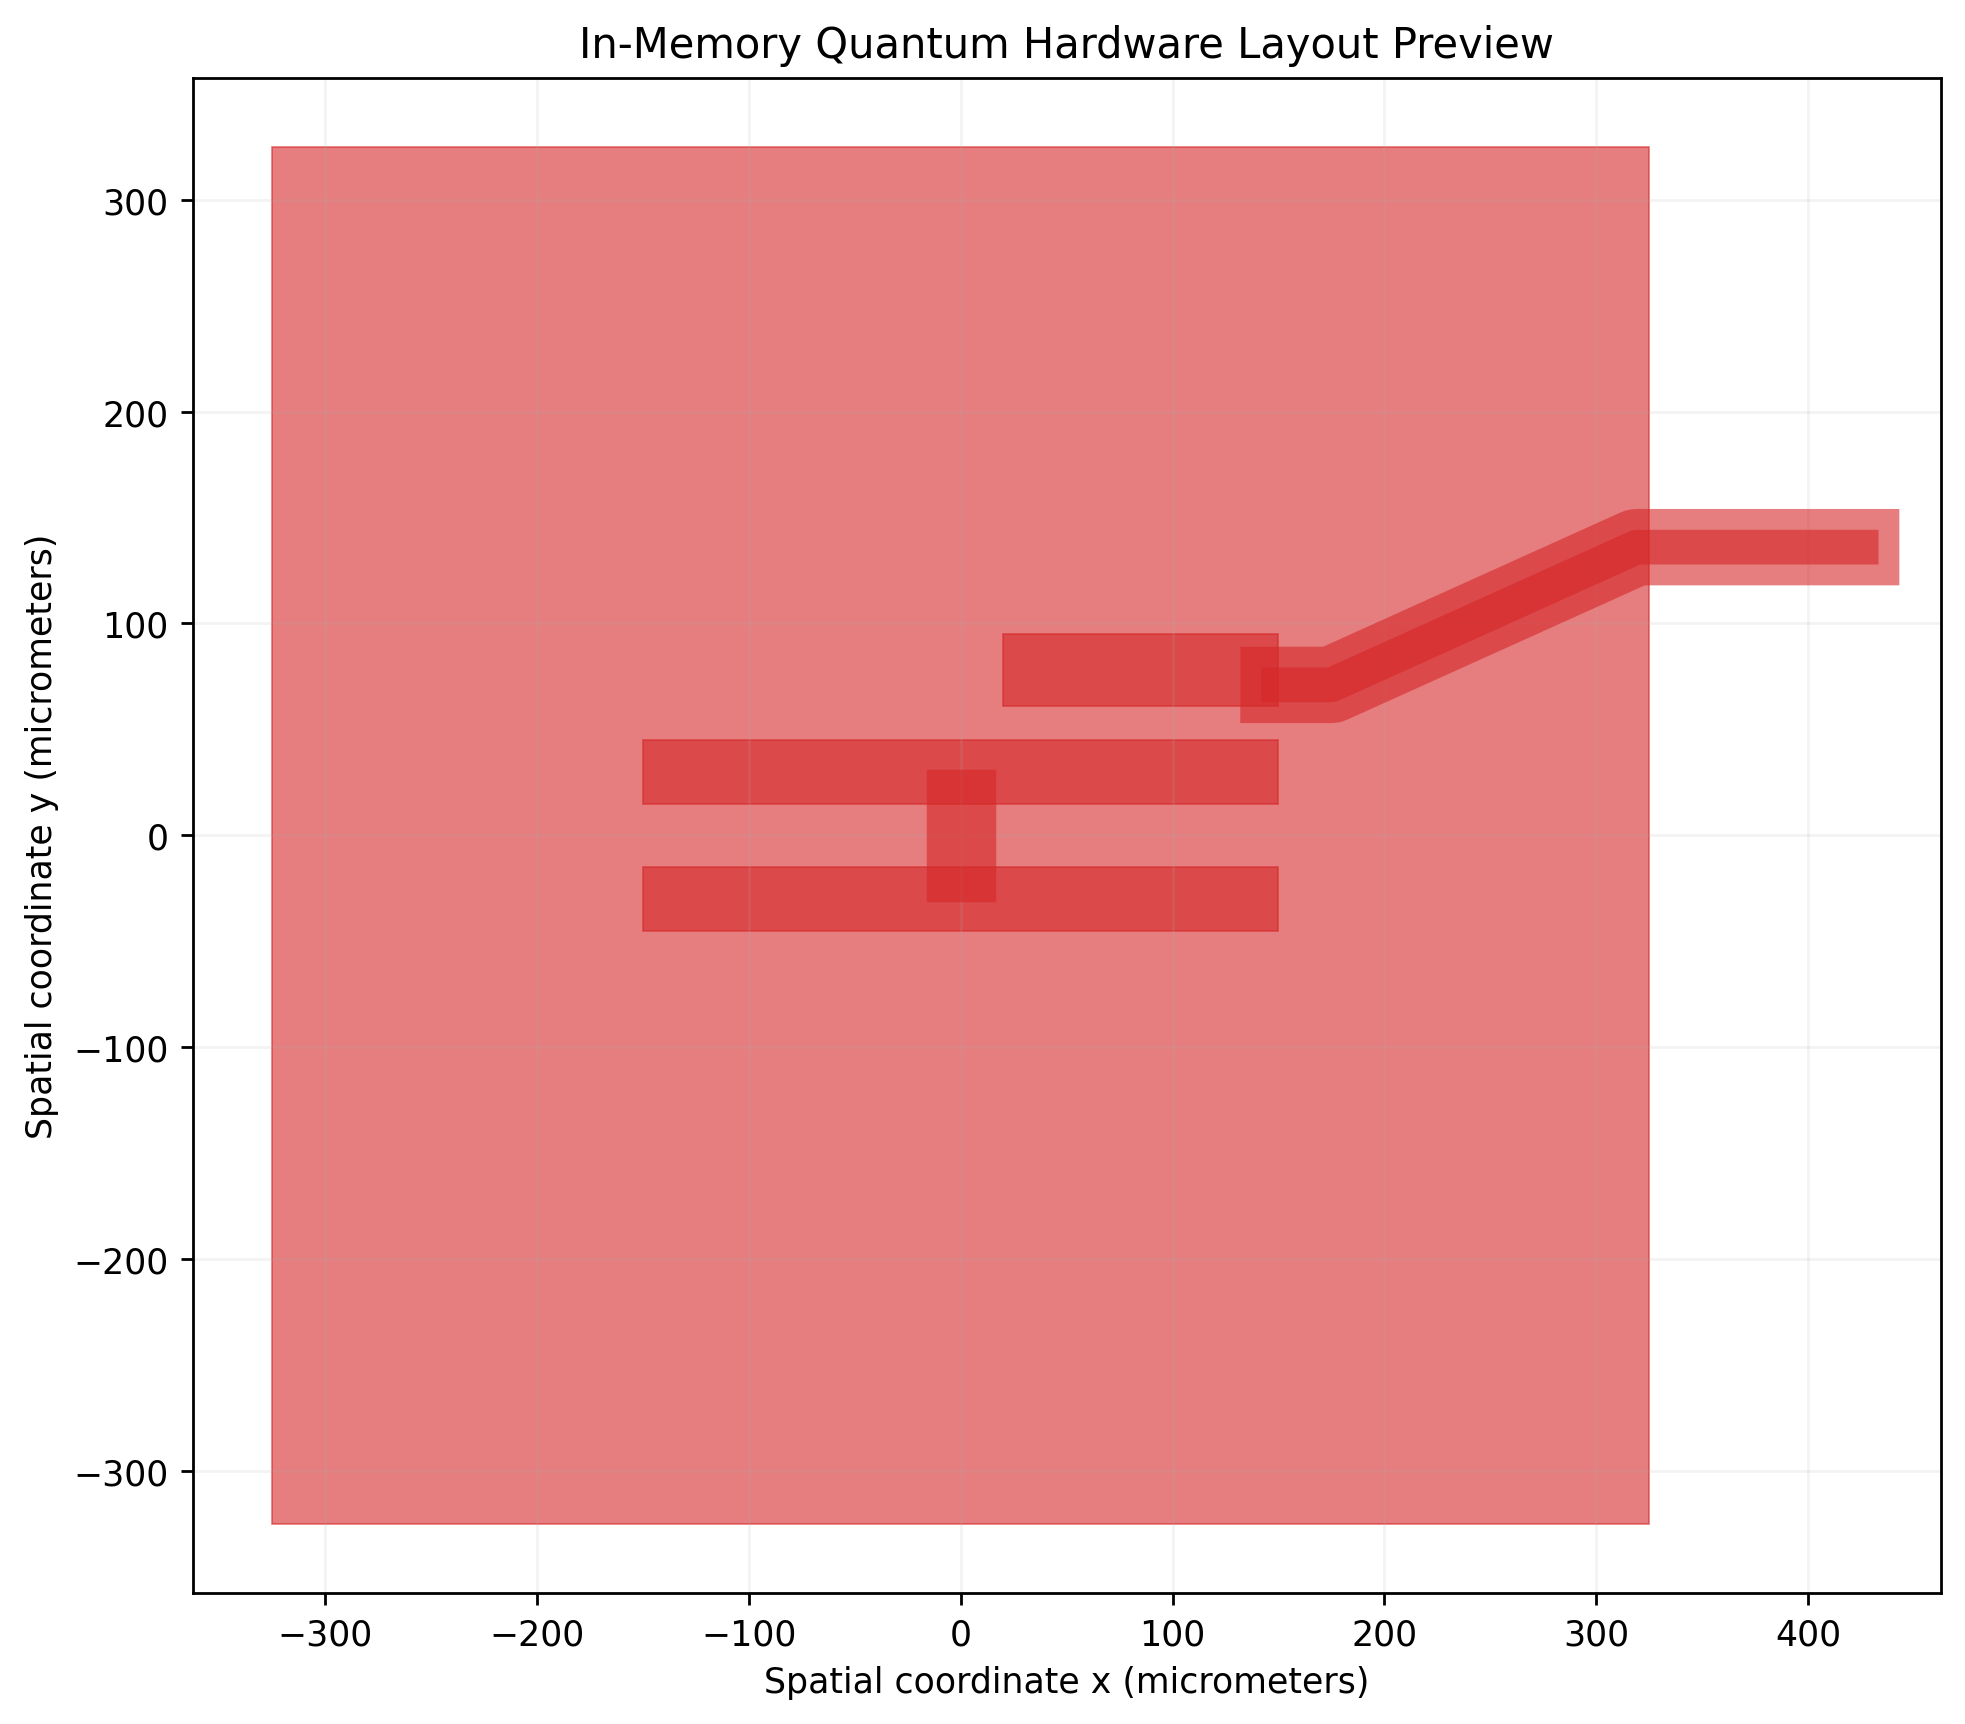

In [15]:
#@title 9. Direct In-Memory Layout Visualization
"""Extract and render the quantum hardware geometry directly from active memory.
"""

from typing import Any, Final
import collections.abc

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

# =============================================================================
# CONTROL KNOBS
# =============================================================================

PLOT_DPI: Final[int] = 250
FIGURE_WIDTH: Final[float] = 10.0
FIGURE_HEIGHT: Final[float] = 7.0
QMETAL_DESIGN_UNIT_TO_UM: Final[float] = 1000.0

LAYER_COLORS: Final[dict[int, str]] = {
    1: "#d62728",
    20: "#2ca02c",
}
DEFAULT_COLOR: Final[str] = "#1f77b4"


def configure_plot_parameters() -> None:
    """Apply the mandated typographical and resolution settings to the global environment."""
    mpl.rcParams["figure.dpi"] = PLOT_DPI
    mpl.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
    mpl.rcParams["font.weight"] = "normal"


def extract_polygon_coordinates(geometry: Any) -> collections.abc.Iterable[np.ndarray]:
    """Yield exterior coordinate arrays from a polygon geometry object."""
    geom_type = getattr(geometry, "geom_type", "")
    if geom_type == "Polygon":
        yield np.asarray(geometry.exterior.coords)
    elif geom_type == "MultiPolygon":
        for polygon in geometry.geoms:
            yield np.asarray(polygon.exterior.coords)


def extract_path_coordinates(geometry: Any) -> collections.abc.Iterable[np.ndarray]:
    """Yield coordinate arrays from a linestring geometry object."""
    geom_type = getattr(geometry, "geom_type", "")
    if geom_type in {"LineString", "LinearRing"}:
        yield np.asarray(geometry.coords)
    elif geom_type == "MultiLineString":
        for line in geometry.geoms:
            yield np.asarray(line.coords)


def plot_active_design_memory(design: Any) -> None:
    """Render the active Qiskit Metal design directly from memory utilizing IPython display."""
    configure_plot_parameters()

    figure, axes = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
    tables = getattr(design.qgeometry, "tables", {})

    for table_name, table in tables.items():
        if table is None or "geometry" not in table.columns:
            continue

        for _, row in table.iterrows():
            geometry = row.get("geometry")
            layer = int(row.get("layer", 1))
            assigned_color = LAYER_COLORS.get(layer, DEFAULT_COLOR)

            for points in extract_polygon_coordinates(geometry):
                scaled_points = points * QMETAL_DESIGN_UNIT_TO_UM
                closed_polygon = np.vstack([scaled_points, scaled_points[0]])
                axes.fill(
                    closed_polygon[:, 0],
                    closed_polygon[:, 1],
                    color=assigned_color,
                    alpha=0.6,
                    edgecolor=assigned_color,
                    linewidth=0.5
                )

            for points in extract_path_coordinates(geometry):
                scaled_points = points * QMETAL_DESIGN_UNIT_TO_UM
                width = float(row.get("width", 0.010)) * QMETAL_DESIGN_UNIT_TO_UM

                axes.plot(
                    scaled_points[:, 0],
                    scaled_points[:, 1],
                    color=assigned_color,
                    alpha=0.6,
                    linewidth=max(width, 1.0)
                )

    axes.set_aspect("equal", adjustable="box")
    axes.set_xlabel("Spatial coordinate x (micrometers)")
    axes.set_ylabel("Spatial coordinate y (micrometers)")
    axes.set_title("In-Memory Quantum Hardware Layout Preview")
    axes.grid(True, alpha=0.15)

    figure.tight_layout()

    # We aggressively display the figure object to bypass the silent Agg backend limitations
    display(figure)

    # We close the figure immediately to free system memory
    plt.close(figure)


if "QUANTUM_DESIGN" in globals():
    plot_active_design_memory(QUANTUM_DESIGN)
else:
    print("The design object is currently unavailable in the active memory state.")

In [10]:
#@title Download helper
from google.colab import files

files.download(str(MERGED_GDS_PATH))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>